# 3D Adhesion Notebook
Calculates adhesive energies between two flat shells for various separation distances.

In [80]:
import numpy as np
import os
import sys
import gzip
import subprocess
import importlib
import pathlib
import shutil
import yaml
import datetime
import pytz
import time
from scipy.optimize import curve_fit
cwd = os.getcwd()
itop=cwd.find("cgshells/")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT )

from utils.readsim import ReadSim
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D
import utils.run_manager as rm
# from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
version = "v1"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{versionpath}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

# rm.print_header(version)
# rm.make_simpaths_file(JOBDIR,JOB)     # make empty status file for this job

import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline


# Run calculations

In [64]:
emin_list

[3521.85194395847]

In [145]:
1/np.array(emin_list)

array([2.36282707e-05])

In [143]:
epsilon_list

[2.362827066414215e-05]

In [150]:
float(epsilon)

2.362827066414215e-05

In [154]:
f"{epsilon:0.9f}"

'0.000023628'

In [155]:
ysep

'a'

In [146]:
simpath = f"data/{int(dimension)}d/mesh_characteristics/{mesh_name}/t0-{t0:0.3f}/interactions/{pair_ints}/sigma-{sigma:0.5f}-epsilon-{epsilon:0.9f}-soft-{soft_ints}/ysep-{ysep:0.3f}"

ValueError: Unknown format code 'f' for object of type 'str'

In [87]:
tstart = time.time()

dimension = 3
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
wx = 30 * dcore    # mesh width in x 
wy = 30 * dcore    # mesh width in y 
a = 0.316 * dcore    # lattice constant of mesh
mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell
t0 = 1.0 * dcore    # structural thickness

sigma_list = [0.8,0.85,0.95,1.0,1.05]
# sigma_list = [0.25,0.410829,0.636787,0.899922]
epsilon_list = np.ones(len(sigma_list)).tolist()
# epsilon_list =  (1/np.array(emin_list)).tolist()
# ysep_list = np.linspace((t0+dcore)*0.8,(t0+dcore)*1.2,200).tolist() 
ysep_list = np.linspace((t0+dcore)*0.8,(t0+dcore)*1.2,100).tolist() 
# ysep_list = np.linspace((t0+dcore)*0.8,2,100).tolist() 
# ysep_list = np.linspace(1.9,2.2,100).tolist() 

jobcounter = 0
for i in range(len(sigma_list)):   
    
    simcounter = 0
    jobcounter += 1
    
    print("#####################################\n")
    print(f"Setting up job {jobcounter}...")
    
    series_simpaths = [] # append simpaths that will run in series for each job (i.e. different kh values)
    
    for j in range(len(ysep_list)):  
        
        simcounter += 1
        
        print(f"----Preparing simulation {simcounter}...")

        ##### PARTICLE #####
        ### Geometry

        r0 = "flat"   # RMS radius of curvature; set to "flat" for planar plates 
        alpha = 0    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle) 
        theta = 0    # angle principal direction 1 makes with material x-axis

        if r0 == "flat":
            k_0 = 0
        else:
            k_0 = 1/r0    # RMS curvature
        
        # preferred curvatures
        k01 = k_0 * np.cos(alpha)    # principal curvatures
        k02 = k_0 * np.sin(alpha)
        kx_0 = k01 * np.cos(theta)**2 + k02 * np.sin(theta)**2  # curvatures in material directions x, y, xy
        ky_0 = k01 * np.sin(theta)**2 + k02 * np.cos(theta)**2
        kxy_0 = (k01-k02) * np.sin(theta) * np.cos(theta)
        

        ### Elasticity
        kh = 1 # all values in this section are arbitrary
        nuxy = 0.333
        nuz = 0.001
        kvkh = (3*(1-3*nuxy)*(1-nuxy-2*nuz*(t0/a)**2))/(2*nuz*(4*nuz*(t0/a)**2+3*nuxy-1))
        kckh = ((1-3*nuxy)*(1+(t0/a)**2))/(4*nuz*(t0/a)**2+3*nuxy-1)

#         kvkh = 1 
#         kckh = 1 

        ### Interactions
        pair_ints = "patchy" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
        soft_ints = False
        sigma = sigma_list[i]
        epsilon = epsilon_list[i]
        shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
        ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
        wcacut = dcore    # cutoff distance for repulsive wca potential
        softsigma = 5*sigma
        softepsilon = 5e-8 * epsilon
        softshift = 0 #softcore - 2**(1/6)*softsigma
        softcut = 2**(1/6) * softsigma

        ##### SIMULATION #####
        ysep = ysep_list[j]
        config = "stacked" #"dispersed" or "stacked"
        simtype = "emin"
        datascript = "ysep3D"    # script to make data file with, NO .py EXTENSION, "stack3D", "load3D", or "lattice3D"
        nshells = 2
        datagz = True
        trajgz = True
        dumpbonds = False    # whether to calculate and dump bond data
        screen = True    # output lammps log to screen


        ### Stacked config settings
        ki1 = 0 * k01    # principal curvatures for bottom shell in stack
        ki2 = 0 * k02
        theta_i = theta
        kx_i = ki1 * np.cos(theta_i)**2 + ki2 * np.sin(theta_i)**2  # curvatures in material directions x, y, xy
        ky_i = ki1 * np.sin(theta_i)**2 + ki2 * np.cos(theta_i)**2
        kxy_i = (ki1-ki2) * np.sin(theta_i) * np.cos(theta_i)
        xlo = -2*wx
        xhi = 2*wx
        ylo = -2*wy
        yhi = 2*wy
        if r0 != 'flat':
            zlo = -4*r0
            zhi = nshells*r0 + 4*r0
        else:
            zlo = -5*(t0+dcore)
            zhi = nshells*(t0+dcore) + 5*(t0+dcore)

        ### Lattice config settings
#         Nx = 2    # number of particle columns for initial config 
#         Ny = int(nshells/Nx)
#         nshells = int(Nx*Ny)   # true number of shells in simulation
#         k_i = 0    # initial curvature of shells in lattice (need flat for high concentrations)
#         theta = "random"   # orientation of shells in lattice (0 = concave down, np.pi = concave up, "random" = randomly up or down)

        ### Dispersed config settings
#         phi = 0.1    # concentration of molecules (area fraction) - only for MD
#         v0 = wx * (t0 + dcore)    # approx area of monomer
#         lbox = np.sqrt(nshells * v0 / phi)    # side length of (square) sim box to give proper concentration
#         xlo = -lbox/2
#         xhi = lbox/2
#         ylo = -lbox/2
#         yhi = lbox/2
#         zlo = -0.5
#         zhi = 0.5

        ### Dynamics/Minimization Settings
        minstyle = "cg"
        etol = 1e-12
        maxiter = 100000

#         Tstart = 1.0
#         Tstop = Tstart
#         Tdamp = 10
#         seed = 15298
#         timestep = 0.0005
#         runsteps = 10000

        dumpfreq = maxiter
        thermofreq = 100

#         force  = 0.1

        ##### LOGISTICS #####

        ### Simulation Directories
        delete_existing = True    # if True, deletes simulation directory (and .sh files) if it exists before creating again
        simpath = f"data/{int(dimension)}d/mesh_characteristics/{mesh_name}/t0-{t0:0.3f}/interactions/{pair_ints}/sigma-{sigma:0.5f}-epsilon-{epsilon:0.9f}-soft-{soft_ints}/ysep-{ysep:0.3f}"
        load_simpath = False # location of simulation to load in (set to False if not loading in state)
#         load_simpath = f"data/examples/{int(dimension)}d/emin/kh-{kh_load:0.2f}/nshells-{nshells}" # location of simulation to load in (set to False if not loading in state)
#         load_dumpname = -1 # name of trajectory file to load (-1 selects highest integer found, e.g trajectory2.dump)
#         load_frame = -1    # frame number to load in (not timestep! 0 is initial state; -1 is last completed dump)

        ### Computation
        computer = "local"
#         computer = "unity"
        nnodes = 1
        mem = 1 #GB
        tlim_hrs = 3
        tlim_min = 0
        partition = "cpu-preempt"    # requested partition
        jobname = os.path.splitext(os.path.basename(sys.argv[0]))[0]
        requested_walltime = f'{tlim_hrs:02d}:{tlim_min:02d}:00'
        tbuffer = 5 # stop lammps tbuffer minutes before walltime is exceeded
                        # any non-zero value means script will auto resubmit until done
                        # zero means no auto resubmission - job stops when done or if time is exceeded
        px = 2    # number of cpus along x
        py = 2
        pz = 1
        gridfreq = 10000    # check cpu partitioning of simbox every gridfreq steps
        thresh = 1.01    # threshold imbalance to repartition simbox
        maxrestarts = 2    # max number of runs for one job (cluster only, local machine limit is set below to 5)

        # add tstep start variable?
        
        
        #################
        ##### SETUP #####
        #################
        
        print("--------Creating simulation directory...")
        
        ### Make simulation directory
        
        if delete_existing == True:
            if os.path.isdir(f"{PROJECT_ROOT}/{simpath}"):
                print("""----------Simulation directory already exists.
----------Deleting...""")
                shutil.rmtree(f"{PROJECT_ROOT}/{simpath}")
                print("----------Creating new simulation directory...")
        
        os.makedirs(f"{PROJECT_ROOT}/{simpath}", exist_ok=True)
        
        ### Append simpaths to job status file and to series_simpaths
#         print("--------Adding simulation directory to job simpaths file...")
#         rm.update_simpaths_file(JOBDIR,JOB,simpath)
        series_simpaths.append(simpath)

        ###############################
        ##### LAMMPS INPUT SCRIPT #####
        ###############################

        print("--------Writing LAMMPS input file...")
        
        ### Header
        inputcontents = f"""# Coarse-grained shell model - LAMMPS input file
        
units lj
dimension {dimension}
boundary s s s
atom_style molecular
bond_style harmonic
angle_style none
dihedral_style none
improper_style none

processors {px} {py} {pz} grid onelevel

comm_style tiled
"""

        if datagz==True:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps.gz"

"""
        else:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps"

"""
        
        ### Interactions
        if pair_ints == "none":
            inputcontents += "pair_style none"
#         elif pair_ints == "repulsive":
#             inputcontents += f"""
# pair_style hybrid lj/expand {ljcut}
# # upside down bonding 1
# pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# # upside down bonding 2
# pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# # correct bonding
# pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
# pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # center-center
# pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_modify shift yes
# \n
# """
            
        else:
            if soft_ints == True:
                pass
#                 inputcontents += f"""
# pair_style hybrid lj/expand {ljcut}
# # upside down bonding 1
# pair_coeff 1 1 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# pair_coeff 3 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# pair_coeff 1 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# # upside down bonding 2
# pair_coeff 2 2 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# pair_coeff 4 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# pair_coeff 2 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# """
            else:
                inputcontents += f"""
pair_style hybrid lj/expand {ljcut}
"""
#                 inputcontents += f"""
# pair_style hybrid lj/expand {ljcut}
# # upside down bonding 1
# pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# # upside down bonding 2
# pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# """

        
            if pair_ints == "1patch":
                pass
#                 inputcontents += f"""
# # correct bonding
# pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
# pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
# pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_modify shift yes
# """
            elif pair_ints == "patchy":
                inputcontents += f"""
# attractive interactions
pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} 
pair_coeff 2 5 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} 
pair_coeff 3 6 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} 

# repulsive interactions
pair_coeff 1 5 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 1 6 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 2 6 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
pair_coeff 3 5 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}

# no interactions
pair_coeff 1 1 none
pair_coeff 2 2 none
pair_coeff 3 3 none
pair_coeff 4 4 none
pair_coeff 5 5 none
pair_coeff 6 6 none
pair_coeff 1 2 none
pair_coeff 1 3 none
pair_coeff 2 3 none
pair_coeff 4 5 none
pair_coeff 4 6 none
pair_coeff 5 6 none

# shift energy at cutoff to zero
pair_modify shift yes
\n
"""
                
            elif pair_ints == "attractive":
                pass
#                 inputcontents += f"""
# # correct bonding
# pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
# pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
# pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
# pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
# pair_modify shift yes
# \n
# """

                
        # Fixes
        if dimension == 2:
            inputcontents += "fix 0 all enforce2d"
        if simtype == "md":
            inputcontents += f"""
fix 1 all langevin {Tstart} {Tstop} {Tdamp} {seed}
fix 2 all nve
"""
            
#         inputcontents += f"""
# fix 3 all rigid molecule
# fix 4 all setforce NULL 0.0 NULL
# fix 4 all setforce 0.0 0.0 0.0

# group redge id {Nbeads:g} {2*Nbeads:g}
# fix 5 redge setforce {force:f} 0.0 0.0
# fix 5 redge addforce {force:f} 0.0 0.0
# group ledge id {1:g} {Nbeads+1:g}
# fix 6 ledge setforce {-force:f} 0.0 0.0
# fix 6 ledge addforce {force:f} 0.0 0.0"""

        if simtype == "emin":
            inputcontents += f"""
fix 4 all setforce 0.0 0.0 0.0
"""

        inputcontents += f"""
fix 7 all balance {gridfreq} {thresh} rcb

neigh_modify exclude molecule/intra all every 5 delay 0 check yes one 200000 page 2000000

thermo_style custom step etotal ke pe epair ebond temp press
thermo {thermofreq}
thermo_modify norm no
"""
        
        if dumpbonds == True:
            inputcontents += f"""
compute btype all property/local btype
compute batom1 all property/local batom1
compute batom2 all property/local batom2
compute bdist all bond/local dist
compute bpot all bond/local engpot
dump 2 all local {dumpfreq} bonds.dump.gz index c_btype c_batom1 c_batom2 c_bdist c_bpot
"""
#     fdata.write("\ndump 1 all custom {} {}/trajectory.dump mol id type x y z".format(dumpfreq,simpath))

        if trajgz==True:
            inputcontents += f"""
dump 1 all custom/gz {dumpfreq} trajectory${{stage}}.dump.gz mol id type x y z
dump_modify 1 append no sort id
"""
        else:
            inputcontents += f"""
dump 1 all custom {dumpfreq} trajectory${{stage}}.dump mol id type x y z
dump_modify 1 append no sort id
"""

        if simtype == "md":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
timestep {timestep}
run {runsteps} upto
write_restart restart.final
"""
        elif simtype == "emin":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
min_style {minstyle}
minimize {etol} 0.0 {maxiter} {10*maxiter}
write_restart restart.final
"""        

        # Write LAMMPS input file
        with open(f"{PROJECT_ROOT}/{simpath}/in.lammps", "w") as f:
            f.write(inputcontents)
            
        
        
        ###############################
        ##### WRITE METADATA FILE #####
        ###############################

        print("--------Writing metadata file...")
        
        params = {

            'particle':{
                'geometry':{
                    'dimension':dimension,
                    'dcore':dcore,
                    'a':a,
                    'wx':wx,
                    'wy':wy,
                    'mesh_name':mesh_name,
                    't0':t0,
                    'r0':r0,
                    'k_0':k_0,
                    'alpha':alpha,
                    'theta':theta,
                    'k01':float(k01),
                    'k02':float(k02),
                    'kx_0':float(kx_0),
                    'ky_0':float(ky_0),
                    'kxy_0':float(kxy_0)
                },
                'elasticity':{
                    'nuxy':nuxy,
                    'nuz':nuz,
                    'kh':kh,
                    'kckh':kckh,
                    'kvkh':kvkh
                },
                'interactions':{
                    'pair_ints':pair_ints,
                    'soft_ints':int(soft_ints),
                    'sigma':sigma,
                    'epsilon':epsilon,
                    'shift':shift,
                    'ljcut':ljcut,
                    'wcacut':wcacut

                },
            },

            'simulation':{
                'simtype':simtype,
                'config':config,
                'nshells':nshells,
                'datascript':datascript,
                'xlo':float(xlo),
                'xhi':float(xhi),
                'ylo':float(ylo),
                'yhi':float(yhi),
                'zlo':float(zlo),
                'zhi':float(zhi),
                'simbox_x':float(xhi-xlo),
                'simbox_y':float(yhi-ylo),
                'simbox_z':float(zhi-zlo),
                'thermofreq':thermofreq,
                'dumpfreq':dumpfreq,
                'datagz':datagz,
                'trajgz':trajgz,
                'dumpbonds':dumpbonds


            },

            'logistics':{
                'computer':computer,
                'jobname':jobname,
                'simpath':simpath,
                'tbuffer':tbuffer,
                'run_counter':0

            }
        }

        if soft_ints == True:
            softparams = {'softsigma':softsigma,'softepsilon':softepsilon,
                    'softshift':softshift,'softcut':softcut}
            params['particle']['interactions'].update(softparams)

        if simtype == "emin":
            eminparams = {'minstyle':minstyle,'etol':etol,'maxiter':maxiter}
            params['simulation'].update(eminparams)

        if simtype == "md":
            mdparams = {'Tstart':Tstart,'Tstop':Tstop,'Tdamp':Tdamp,'seed':seed,
                        'timestep':timestep,'runsteps':runsteps}
            params['simulation'].update(mdparams)

        if config == "dispersed":
            disp_params = {'phi':phi}
            params['simulation'].update(disp_params)
            
        if config == "lattice":
            disp_params = {'phi':phi,"Nx":Nx,"Ny":Ny,'k_i':k_i,"theta":theta}
            params['simulation'].update(disp_params) 
         
        if config == "stacked":
            stack_params = {'ki1':float(ki1),'ki2':float(ki2),'theta_i':theta_i,'kx_i':float(kx_i),'ky_i':float(ky_i),'kxy_i':float(kxy_i),'ysep':ysep}
            params['simulation'].update(stack_params)

        if computer != 'local':
            clusterparams = {'nnodes':nnodes,'cpus':px*py*pz,'mem':mem,
                             'partition':partition,'requested_walltime':requested_walltime}
            params['logistics'].update(clusterparams)

        if load_simpath == False:
            loadparams = {'load_simpath':int(load_simpath)}
        else:
            loadparams = {'load_simpath':load_simpath,'load_dumpname':load_dumpname,'load_frame':int(load_frame)}
        params['logistics'].update(loadparams)


        # Write YAML metadata
        rm.write_metadata(f"{PROJECT_ROOT}/{simpath}",params)
        
        
        print(f"----Simulation {simcounter} prepared.")
        
        ################################
        ##### RUN ON LOCAL MACHINE #####
        ################################

        if computer == "local":
            nrestarts = 1
            maxrestarts = 5    # max number of runs to try to finish job
            restartjob = True
            while (restartjob==True) and (nrestarts<=maxrestarts):
                print(f"Running job {jobcounter} sim {simcounter}.{nrestarts} on local machine...")

                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")
                # on first run create data file
                if meta['logistics']['run_counter'] == 0:
                    make_data = rm.load_class('DataScripts',f'{datascript}','make_data',base_module=f"utils.curvsim.{version}")
                    t1 = time.time()
                    make_data(simpath)
                    t2 = time.time()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True,sub='logistics',params={'datatime':t2-t1})
                    print(f"Time to create data file: {rm.convert_time(t2-t1)}")

                print("Updating metadata with start time...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",start_times=True)
                print("Executing LAMMPS...")
                ncpus = px*py*pz
                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")    # check what stage to use
                rm.run_lmp(simpath,computer,ncpus,screen,stage = meta['logistics']['run_counter'])
                print("Updating metadata with run info ...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",walltimes=True,steps=True,energies=True)
                if simtype == "emin":
                    result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
                    result.read_log()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",sub="logistics",params = {'stopcriterion':result.why_stop})
                restartjob = rm.check_restart(f"{PROJECT_ROOT}/{simpath}")
                if restartjob:
                    print("Reached walltime limit.  Restarting new run...")
                    nrestarts += 1
                    if nrestarts <= maxrestarts:
                        rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True)
                print("\n#####################################")
            
            if nrestarts > maxrestarts:
                print(f"Max number of restarts exceeded ({maxrestarts}).")
                print("#####################################")
    
    #################################
    ##### RUN ON REMOTE CLUSTER #####
    #################################
    
    if computer != "local":
        

        ##################################
        ##### SBATCH SUBMISSION FILE #####
        ##################################

        print(f"----Writing sbatch submission file for job {jobcounter}...")
        # name of sbatch .sh file (no extension)
        if simtype == "emin":
            shname = f"nshells-{nshells}"    
        elif simtype == "md":
            shname = f"nshells-{nshells}-phi-{phi:0.5f}-kT-{kT:0.5f}"  
        ncpus = px*py*pz
        sbatchcontents = f"""#!/bin/bash
#SBATCH -N {nnodes} # Number of Nodes
#SBATCH -n {ncpus} # Number of Tasks (cpus)
#SBATCH --mem={mem}G # Requested Memory
#SBATCH -p {partition} # Partition
#SBATCH --constraint=mpi
#SBATCH -t {tlim_hrs:02d}:{tlim_min:02d}:00 # Job time limit
#SBATCH -o {JOBDIR}/{JOB}-sbatch/{shname}-%j.out # %j = job ID

### load modules
{rm.cluster_modules(computer)}

### go to project_root directory
cd {PROJECT_ROOT}

python3 -u << 'EOF' 

### python code
"""
            
        sbatchcontents += f"""
### import modules

# standard python packages
import os
import sys
import numpy as np
import subprocess
import importlib
import pathlib
#import shutil
#import yaml
#import datetime
#import pytz
import time

# utils packages and useful paths
import utils.run_manager as rm
from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
from utils.readsim import ReadSim
#JOBDIR = pathlib.Path(__file__).resolve().parents[0]    # absolute path to directory that holds this file
#JOB = os.path.splitext(os.path.basename(sys.argv[0]))[0]    # name of this file without extension
version = "{version}"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{{versionpath}}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

simtype = "{simtype}"

# dependent variables to be run in series
series_simpaths = {series_simpaths}

  
simpaths_torun = []    # list of simulations that need to be run/restarted

# sweep through variable values and find those that need to run/restart
for i in np.arange(len(series_simpaths)):
    simpath = series_simpaths[i]

    # check to see if this value has already run to completion 
    try:
        restartjob = rm.check_restart(f"{{PROJECT_ROOT}}/{{simpath}}")    
            # returns True if in need of restart; False if completed; error if not run yet
    except:
        restartjob = True
        
    if restartjob:    # True if value needs to be run or restarted
        simpaths_torun.append(simpath)

if len(simpaths_torun) > 0:
    # For this job, select first variable value that needs to be run/restarted
    simpath = simpaths_torun[0]
    
    meta = rm.read_metadata(f"{{PROJECT_ROOT}}/{{simpath}}")
    if meta['logistics']['run_counter'] == 0:
        rc = 1
    else: 
        rc = meta['logistics']['run_counter']
    
    rm.print_header(version)
    print(f"Running {{simpath}}")
    print(f"Run number {{rc}}")
    
    # Make datafile if needed (on first run)
    if meta['logistics']['run_counter'] == 0:
        make_data = rm.load_class('DataScripts',f'{datascript}','make_data',base_module=f"utils.curvsim.{{version}}")
        t1 = time.time()
        make_data(simpath)
        t2 = time.time()
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=True,sub='logistics',params={{'datatime':t2-t1}})
        print(f"Compute time to create data file: {{rm.convert_time(t2-t1)}}")


    # Run LAMMPS
    print("Updating metadata with start time...")
    rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",start_times=True)
    print("Executing LAMMPS...")
    ncpus = {ncpus}
    meta = rm.read_metadata(f"{{PROJECT_ROOT}}/{{simpath}}")    # check what stage to use
    rm.run_lmp(simpath,"{computer}",ncpus,{screen},stage = meta['logistics']['run_counter'])
    print("Updating metadata with run info ...")
    rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",walltimes=True,steps=True,energies=True)
    if simtype == "emin":
        result = ReadSim(f"{{PROJECT_ROOT}}/{{simpath}}")
        result.read_log()
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",sub="logistics",params = {{'stopcriterion':result.why_stop}})

    restartjob = rm.check_restart(f"{{PROJECT_ROOT}}/{{simpath}}")  

    # Submit sbatch again if run hasn't completed
    if restartjob:
        if (rc < {maxrestarts}):
            print("Job incomplete.  Resubmitting...")
            sbatch = subprocess.run(['sbatch','{JOBDIR}/{JOB}-sbatch/{shname}.sh'],
                                stdout=subprocess.PIPE,universal_newlines = True)

            jobid = int(sbatch.stdout[len('Submitted batch job '):])
            rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=True,submit_times=True,jobids = jobid)
        else:
            print("Error:  Exceeded max number of restarts ({maxrestarts}).")
    
    print("Done.")
    
    if len(simpaths_torun) > 1:    # resubmit this .sh file if there are more calculations to do
        print("Submitting next job.")
        simpath = simpaths_torun[1]
        sbatch = subprocess.run(['sbatch','{JOBDIR}/{JOB}-sbatch/{shname}.sh'],
                                stdout=subprocess.PIPE,universal_newlines = True)

        jobid = int(sbatch.stdout[len('Submitted batch job '):])
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=False,submit_times=True,jobids = jobid)


else:
    print("All variable values completed.  No runs left to do for this job.")


EOF
"""
        
        # WRITE SBATCHCONTENTS TO JOBS/*.SH (or some subdirectory)
        if delete_existing == True:
            if jobcounter == 1:
                if os.path.isdir(f"{JOBDIR}/{JOB}-sbatch"):
                    shutil.rmtree(f"{JOBDIR}/{JOB}-sbatch")
        os.makedirs(f"{JOBDIR}/{JOB}-sbatch", exist_ok=True)
        with open(f"{JOBDIR}/{JOB}-sbatch/{shname}.sh", "w") as f:
            f.write(sbatchcontents)

        ###############################
        ##### SUBMIT JOB TO QUEUE #####
        ###############################

        print(f"----Submitting job {jobcounter} to queue...")
        
        sbatch = subprocess.run(['sbatch',f"{JOBDIR}/{JOB}-sbatch/{shname}.sh"],
                                stdout=subprocess.PIPE,universal_newlines = True)
        
        jobid = int(sbatch.stdout[len('Submitted batch job '):])
        

        ###########################
        ##### UPDATE METADATA #####
        ###########################

        print(f"----Updating metadata file...")
        rm.update_metadata(f"{PROJECT_ROOT}/{series_simpaths[0]}",submit_times=True,jobids = jobid)

        print(f"Job {jobcounter} fully prepared and submitted.\n")
        print("#####################################")
    


tend = time.time()

#####################################

Setting up job 1...
----Preparing simulation 1...
--------Creating simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 1 prepared.
Running job 1 sim 1.1 on local machine...
Using ysep3D.py to create data file...
nshells = 2
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 6.128509044647217sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -10) to (60 60 14)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  42624 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  274632 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of s

...making data file
Time to create data file: 0d - 0hrs 0min 6.068457126617432sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -10) to (60 60 14)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  42624 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  274632 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.220 seconds
  read_data CPU = 0.582 seconds
New timer settings: style=normal  mode=nosync  timeout=02:55:00
Generated 0 of 15 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update every 1 steps, delay 0 steps, check yes
  max neighbors/atom: 200000, page size: 2000000
  master list d

  9 = max bonds/atom
  reading bonds ...
  274632 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.287 seconds
  read_data CPU = 0.637 seconds
New timer settings: style=normal  mode=nosync  timeout=02:55:00
Generated 0 of 15 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update every 1 steps, delay 0 steps, check yes
  max neighbors/atom: 200000, page size: 2000000
  master list distance cutoff = 4.3
  ghost atom cutoff = 4.3
  binsize = 2.15, bins = 15 15 2
  2 neighbor lists, perpetual/occasional/extra = 2 0 0
  (1) pair lj/expand, perpetual, skip from (2)
      attributes: half, newton on
      pair build: skip
      stencil: none
      bin: none
  (2) neighbor class addition, perpetual
      attrib

   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.207 seconds
  read_data CPU = 0.556 seconds
New timer settings: style=normal  mode=nosync  timeout=02:55:00
Generated 0 of 15 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update every 1 steps, delay 0 steps, check yes
  max neighbors/atom: 200000, page size: 2000000
  master list distance cutoff = 4.3
  ghost atom cutoff = 4.3
  binsize = 2.15, bins = 15 15 2
  2 neighbor lists, perpetual/occasional/extra = 2 0 0
  (1) pair lj/expand, perpetual, skip from (2)
      attributes: half, newton on
      pair build: skip
      stencil: none
      bin: none
  (2) neighbor class addition, perpetual
      attributes: half, newton on
      pair build: half/bin/newton
      stencil: half/bin/3d
      bin: standard
Setting up cg style minimization ...
  Unit style    : lj
  Current step  : 0
  Walltime left : 2:54:59.99
Per MPI rank memory alloca

Per MPI rank memory allocation (min/avg/max) = 59.17 | 59.2 | 59.24 Mbytes
   Step         TotEng         KinEng         PotEng         E_pair         E_bond          Temp          Press     
         0   5516567.7      0              5516567.7      5516567.7      0              0              12742.205    
         1   5516567.7      0              5516567.7      5516567.7      0              0              12742.205    
Loop time of 0.0900056 on 4 procs for 1 steps with 42624 atoms

99.3% CPU use with 4 MPI tasks x no OpenMP threads

Minimization stats:
  Stopping criterion = search direction is not downhill
  Energy initial, next-to-last, final = 
      5516567.74296588   5516567.74296588   5516567.74296588
  Force two-norm initial, final = 0 0
  Force max component initial, final = 0 0
  Final line search alpha, max atom move = 0 0
  Iterations, force evaluations = 1 0

MPI task timing breakdown:
Section |  min time  |  avg time  |  max time  |%varavg| %total
----------------------

...

Per MPI rank memory allocation (min/avg/max) = 59.19 | 59.23 | 59.27 Mbytes
   Step         TotEng         KinEng         PotEng         E_pair         E_bond          Temp          Press     
         0  -154772.21      0             -154772.21     -154772.21      0              0             -89.030887    
         1  -154772.21      0             -154772.21     -154772.21      0              0             -89.030887    
Loop time of 0.108993 on 4 procs for 1 steps with 42624 atoms

99.3% CPU use with 4 MPI tasks x no OpenMP threads

Minimization stats:
  Stopping criterion = search direction is not downhill
  Energy initial, next-to-last, final = 
     -154772.212233213  -154772.212233213  -154772.212233213
  Force two-norm initial, final = 0 0
  Force max component initial, final = 0 0
  Final line search alpha, max atom move = 0 0
  Iterations, force evaluations = 1 0

MPI task timing breakdown:
Section |  min time  |  avg time  |  max time  |%varavg| %total
----------------------

...making data file
Time to create data file: 0d - 0hrs 0min 5.924236059188843sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-60 -60 -10) to (60 60 14)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  42624 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  274632 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.192 seconds
  read_data CPU = 0.532 seconds
New timer settings: style=normal  mode=nosync  timeout=02:55:00
Generated 0 of 15 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update every 1 steps, delay 0 steps, check yes
  max neighbors/atom: 200000, page size: 2000000
  master list d

  9 = max bonds/atom
  reading bonds ...
  274632 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       
    15 = max # of 1-2 neighbors
   166 = max # of 1-3 neighbors
  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.190 seconds
  read_data CPU = 0.537 seconds
New timer settings: style=normal  mode=nosync  timeout=02:55:00
Generated 0 of 15 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update every 1 steps, delay 0 steps, check yes
  max neighbors/atom: 200000, page size: 2000000
  master list distance cutoff = 5.55
  ghost atom cutoff = 5.55
  binsize = 2.775, bins = 11 11 2
  2 neighbor lists, perpetual/occasional/extra = 2 0 0
  (1) pair lj/expand, perpetual, skip from (2)
      attributes: half, newton on
      pair build: skip
      stencil: none
      bin: none
  (2) neighbor class addition, perpetual
      att

  2058 = max # of 1-4 neighbors
    73 = max # of special neighbors
  special bonds CPU = 0.190 seconds
  read_data CPU = 0.532 seconds
New timer settings: style=normal  mode=nosync  timeout=02:55:00
Generated 0 of 15 mixed pair_coeff terms from geometric mixing rule
Neighbor list info ...
  update every 1 steps, delay 0 steps, check yes
  max neighbors/atom: 200000, page size: 2000000
  master list distance cutoff = 5.55
  ghost atom cutoff = 5.55
  binsize = 2.775, bins = 11 11 2
  2 neighbor lists, perpetual/occasional/extra = 2 0 0
  (1) pair lj/expand, perpetual, skip from (2)
      attributes: half, newton on
      pair build: skip
      stencil: none
      bin: none
  (2) neighbor class addition, perpetual
      attributes: half, newton on
      pair build: half/bin/newton
      stencil: half/bin/3d
      bin: standard
Setting up cg style minimization ...
  Unit style    : lj
  Current step  : 0
  Walltime left : 2:54:59.99
Per MPI rank memory allocation (min/avg/max) = 59.19 | 

Per MPI rank memory allocation (min/avg/max) = 59.19 | 59.23 | 59.27 Mbytes
   Step         TotEng         KinEng         PotEng         E_pair         E_bond          Temp          Press     
         0  -129243.04      0             -129243.04     -129243.04      0              0             -74.283055    
         1  -129243.04      0             -129243.04     -129243.04      0              0             -74.283055    
Loop time of 0.108782 on 4 procs for 1 steps with 42624 atoms

99.3% CPU use with 4 MPI tasks x no OpenMP threads

Minimization stats:
  Stopping criterion = search direction is not downhill
  Energy initial, next-to-last, final = 
      -129243.04252237   -129243.04252237   -129243.04252237
  Force two-norm initial, final = 0 0
  Force max component initial, final = 0 0
  Final line search alpha, max atom move = 0 0
  Iterations, force evaluations = 1 0

MPI task timing breakdown:
Section |  min time  |  avg time  |  max time  |%varavg| %total
----------------------

In [88]:
print(rm.convert_time(tend-tstart))

0d - 0hrs 59min 39.13549208641052sec


In [89]:
epsilon_list

[1.0, 1.0, 1.0, 1.0, 1.0]

# Read sims and plot

In [90]:
##### PARTICLE #####
### Geometry
dimension = 3
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
wx = 30 * dcore    # mesh width in x 
wy = 30 * dcore    # mesh width in y 
a = 0.316 * dcore    # lattice constant of mesh
mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell
t0 = 1.0 * dcore    # structural thickness

# sigma_list = [0.25,0.3,0.35,0.410829,0.45,0.5,0.55,0.6,0.6367897,0.7,0.75,0.899922]
# epsilon_list = [1.4464536457630208e-05,1.0422868180740177e-05, 8.583244858013735e-06,
#                 7.149441531645948e-06,6.466847477837022e-06, 5.764507277641722e-06, 
#                 5.1973129665786396e-06, 4.728320896676036e-06,4.4305240601244645e-06,
#                 3.991183857451125e-06, 3.696195866199495e-06,3.0055178781968955e-06]
# sigma_list = [0.25,0.410829,0.636787,0.899922]
# epsilon_list = np.ones(len(sigma_list)).tolist()
# epsilon_list = [0.0002839415216518233]
# ysep_list = np.linspace((t0+dcore)*0.8,(t0+dcore)*1.2,100.tolist() 
# sigma_list = [0.25]
# epsilon_list = [1.4464536457630208e-05]
ysep_list = "all"   # plot all ysep simulations found in mesh directory

pair_ints = "patchy" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
soft_ints = False

sigmas = []
yseps = []
eadhs = []
jobcounter = 0
for i in range(len(sigma_list)):   
    sigma = sigma_list[i]
    epsilon = epsilon_list[i]
    parentsimpath = f"data/{int(dimension)}d/mesh_characteristics/{mesh_name}/t0-{t0:0.3f}/interactions/{pair_ints}/sigma-{sigma:0.5f}-epsilon-{epsilon:0.9f}-soft-{soft_ints}"
    series_simpaths = [] # append simpaths for plotting (i.e. different ysep values)
    
    if ysep_list == "all":
        yseplist = []
        files = os.listdir(f"{PROJECT_ROOT}/{parentsimpath}")
        for f in files:
            ysep = float(f[5:])
            yseplist.append(ysep)
            series_simpaths.append(f"{parentsimpath}/{f}")
    
    else:
        yseplist = ysep_list
        for j in range(len(ysep_list)):  
            ysep  = ysep_list[j]
            simpath = f"{parentsimpath}/ysep-{ysep:0.3f}" # path to simulation directory (relative to PROJECT_ROOT)
            series_simpaths.append(simpath)
    
    sigmalist = []
    eadhlist = []
    for s in series_simpaths:
        logname = "log.lammps"
        result = ReadSim(f"{PROJECT_ROOT}/{s}")
        result.read_log(logname=logname)
        eadh = result.energyf
        eadhlist.append(eadh)
        sigmalist.append(sigma)
    eadhs.append(eadhlist)
    sigmas.append(sigmalist)
    yseps.append(yseplist)
    

sigma_list = np.array([0.8, 0.85, 0.95, 1.0, 1.05])
epsilon_list = np.array([1.0, 1.0, 1.0, 1.0, 1.0])
emin_list = np.array([290919.969630336, 311668.692980693, 354173.393269389, 376123.160838575, 398413.176729824])
tmin_list = np.array([1.907, 1.899, 1.891, 1.883, 1.875])


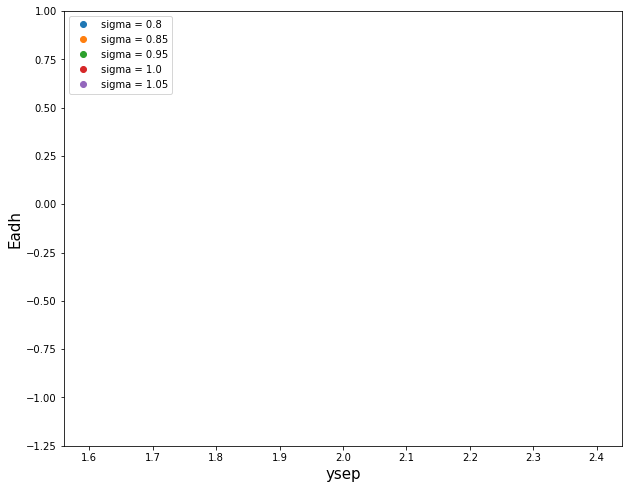

In [91]:

fig, ax = plt.subplots(1,1,figsize=(10,8))
for i in range(len(sigmas)):
    ax.plot(np.array(yseps[i]),np.array(eadhs[i]),"o",label=f"sigma = {sigmas[i][0]}")
# ax.set_xlim(0,1.5)
# ax.set_ylim(-120000,10)
ax.set_ylim(-1.25,1)
ax.legend()
ax.set_xlabel("ysep",fontsize=15)
ax.set_ylabel("Eadh",fontsize=15)

emin_list = []
tmin_list = []
for i in range(len(eadhs)):
    imin = np.argmin(eadhs[i])
    emin = np.abs(eadhs[i][imin])
    tmin = np.abs(yseps[i][imin])
    emin_list.append(emin)
    tmin_list.append(tmin)
print(f"sigma_list = np.array({sigma_list})")
print(f"epsilon_list = np.array({epsilon_list})")
print(f"emin_list = np.array({emin_list})")
print(f"tmin_list = np.array({tmin_list})")

In [92]:
emin_list

[290919.969630336,
 311668.692980693,
 354173.393269389,
 376123.160838575,
 398413.176729824]

In [94]:
sigma_list

[0.8, 0.85, 0.95, 1.0, 1.05]

In [93]:
1/np.array(emin_list)

array([3.43737146e-06, 3.20853529e-06, 2.82347579e-06, 2.65870360e-06,
       2.50995715e-06])

sigma_list = np.array([0.25, 0.3, 0.35, 0.410829, 0.45, 0.5, 0.55, 0.6, 0.6367897, 0.7, 0.75, 0.899922])
alist = np.array([919.6685776458147, 596.6207042660825, 463.144219626777, 332.12675343032197, 260.54460451775367, 193.5390668146613, 167.41273303781477, 131.06813891702313, 110.68392283564715, 90.31965849096578, 82.29211716072778, 54.721496353439356])
tmin_list = np.array([1.974, 1.966, 1.958, 1.95, 1.946, 1.942, 1.934, 1.93, 1.926, 1.918, 1.91, 1.893])
x0list = np.array([1.974141752242367, 1.9666588602858073, 1.9605969561201844, 1.9534733461780673, 1.9486664534850393, 1.943306895506775, 1.937090005322642, 1.9318043752930956, 1.9272076344513784, 1.9199824623004638, 1.9143891003214468, 1.8971542860579025])
emin_list = np.array([0.999657200442863, 1.00000000000215, 1.00000000000106, 0.999650101603849, 0.999999999997878, 1.00000000000132, 1.0000000000005, 1.00000000000222, 0.999961828225116, 0.999999999999744, 1.0000000000065, 1.00003909142777])
y0list = np.array([-1.0001497397345556, 

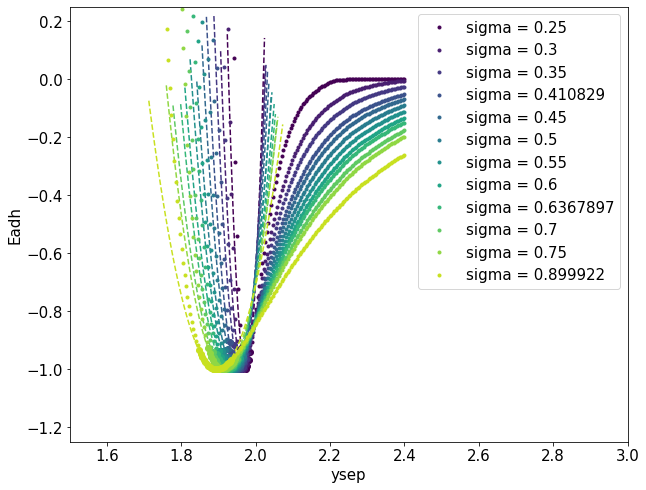

In [86]:
def harmonicfit(x,a,x0,y0):
    return 0.5*a*(x-x0)**2 + y0
alist = []
x0list = []
y0list = []

cmap = plt.cm.viridis

fig, ax = plt.subplots(1,1,figsize=(10,8))
for i in range(len(sigma_list)):
    mask = (np.array(yseps[i])-tmin_list[i])**2 <= (0.05*sigma_list[i])**2
    ax.plot(np.array(yseps[i])[mask],np.array(eadhs[i])[mask],"o",color = cmap(i/(len(sigma_list))))
    ax.plot(np.array(yseps[i]),np.array(eadhs[i]),".",label=f"sigma = {sigma_list[i]}", color = cmap(i/(len(sigma_list))))
    xdata = np.array(yseps[i])[mask]
    ydata = np.array(eadhs[i])[mask]
    params, err = curve_fit(harmonicfit,xdata,ydata,p0=np.array([1,tmin_list[i],-emin_list[i]]))
    (abest,x0best,y0best)=params
    alist.append(abest)
    x0list.append(x0best)
    y0list.append(y0best)
    xfit = np.linspace(tmin_list[i]-0.2*sigma_list[i],tmin_list[i]+0.2*sigma_list[i],100)
    ax.plot(xfit,harmonicfit(xfit,abest,x0best,y0best),"--",color = cmap(i/(len(sigma_list))))
    
ax.set_xlim(1.5,3)
# ax.set_ylim(-200,10)
ax.set_ylim(-1.25,0.25)
ax.legend(fontsize=15)
ax.set_xlabel("ysep",fontsize=15)
ax.set_ylabel("Eadh",fontsize=15)
ax.tick_params(labelsize=15)

print(f"sigma_list = np.array({sigma_list})")
print(f"alist = np.array({alist})")
print(f"tmin_list = np.array({tmin_list})")
print(f"x0list = np.array({x0list})")
print(f"emin_list = np.array({emin_list})")
print(f"y0list = np.array({y0list})")
print(f"epsilon_list = np.array({epsilon_list})")



In [39]:
xdata, ydata = zip(*sorted(zip(yseps[0],eadhs[0])))

In [40]:
xdata

(1.6,
 1.604,
 1.608,
 1.612,
 1.616,
 1.62,
 1.624,
 1.628,
 1.632,
 1.636,
 1.64,
 1.644,
 1.648,
 1.652,
 1.656,
 1.66,
 1.664,
 1.668,
 1.672,
 1.676,
 1.68,
 1.684,
 1.688,
 1.692,
 1.696,
 1.701,
 1.705,
 1.709,
 1.713,
 1.717,
 1.721,
 1.725,
 1.729,
 1.733,
 1.737,
 1.741,
 1.745,
 1.749,
 1.753,
 1.757,
 1.761,
 1.765,
 1.769,
 1.773,
 1.777,
 1.781,
 1.785,
 1.789,
 1.793,
 1.797,
 1.801,
 1.805,
 1.809,
 1.813,
 1.817,
 1.821,
 1.825,
 1.829,
 1.833,
 1.837,
 1.841,
 1.845,
 1.849,
 1.853,
 1.857,
 1.861,
 1.865,
 1.869,
 1.873,
 1.877,
 1.881,
 1.885,
 1.889,
 1.893,
 1.897,
 1.902,
 1.906,
 1.91,
 1.914,
 1.918,
 1.922,
 1.926,
 1.93,
 1.934,
 1.938,
 1.942,
 1.946,
 1.95,
 1.954,
 1.958,
 1.962,
 1.966,
 1.97,
 1.974,
 1.978,
 1.982,
 1.986,
 1.99,
 1.994,
 1.998,
 2.002,
 2.006,
 2.01,
 2.014,
 2.018,
 2.022,
 2.026,
 2.03,
 2.034,
 2.038,
 2.042,
 2.046,
 2.05,
 2.054,
 2.058,
 2.062,
 2.066,
 2.07,
 2.074,
 2.078,
 2.082,
 2.086,
 2.09,
 2.094,
 2.098,
 2.103,
 2.107,


sigma_list = np.array([0.25])
alist = np.array([])
tmin_list = np.array([1.974])
x0list = np.array([])
emin_list = np.array([0.999657200442863])
y0list = np.array([])
epsilon_list = np.array([1.4464536457630208e-05])


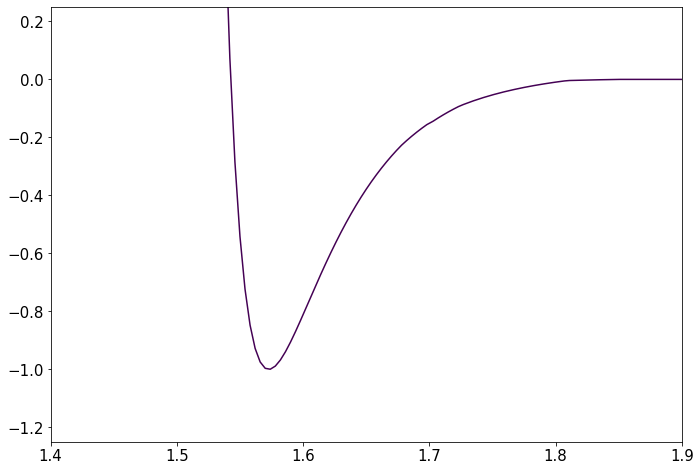

In [49]:
xdata, ydata = zip(*sorted(zip(yseps[0],eadhs[0])))

def harmonicfit(x,a,x0,y0):
    return 0.5*a*(x-x0)**2 + y0
alist = []
x0list = []
y0list = []

cmap = plt.cm.viridis

fig, ax = plt.subplots(1,1,figsize=(np.sqrt(2)*8,8))
for i in range(len(sigma_list)):
    mask = (np.array(xdata)-tmin_list[i])**2 <= (0.05*sigma_list[i])**2
#     ax.plot(np.array(yseps[i])[mask],np.array(eadhs[i])[mask],"o",color = cmap(i/(len(sigma_list))))
    ax.plot(np.array(xdata)-1+0.6,np.array(ydata),"-",label=f"sigma = {sigma_list[i]}", color = cmap(i/(len(sigma_list))))
#     xdata = np.array(yseps[i])[mask]
#     ydata = np.array(eadhs[i])[mask]
#     params, err = curve_fit(harmonicfit,xdata,ydata,p0=np.array([1,tmin_list[i],-emin_list[i]]))
#     (abest,x0best,y0best)=params
#     alist.append(abest)
#     x0list.append(x0best)
#     y0list.append(y0best)
#     xfit = np.linspace(tmin_list[i]-0.2*sigma_list[i],tmin_list[i]+0.2*sigma_list[i],100)
#     ax.plot(xfit,harmonicfit(xfit,abest,x0best,y0best),"--",color = cmap(i/(len(sigma_list))))
    
ax.set_xlim(1.5,3)
# ax.set_ylim(-200,10)
ax.set_ylim(-1.25,0.25)
# ax.legend(fontsize=15)
# ax.set_xlabel("ysep",fontsize=15)
# ax.set_ylabel("Eadh",fontsize=15)
ax.tick_params(labelsize=15)

print(f"sigma_list = np.array({sigma_list})")
print(f"alist = np.array({alist})")
print(f"tmin_list = np.array({tmin_list})")
print(f"x0list = np.array({x0list})")
print(f"emin_list = np.array({emin_list})")
print(f"y0list = np.array({y0list})")
print(f"epsilon_list = np.array({epsilon_list})")

ax.set_xlim(1.4,1.9)

# fig.savefig('plate-plate-energy.pdf')

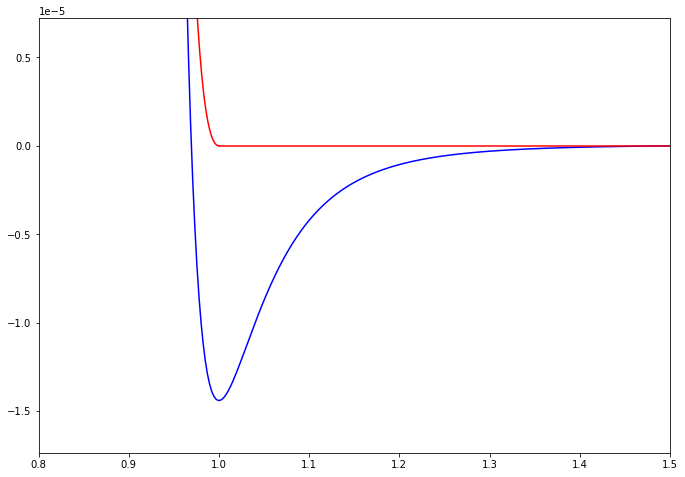

In [79]:
dcore = 1
sigma = sigma_list[0]
epsilon = epsilon_list[0]
ljcut = 6*sigma
wcacut = dcore
shift = dcore - 2**(1/6)*sigma
xlj = np.linspace(0.8*dcore,ljcut,300)
ulj = 4*epsilon*( (sigma/(xlj-shift))**12 - (sigma/(xlj-shift))**6 ) - 4*epsilon*( (sigma/(ljcut-shift))**12 - (sigma/(ljcut-shift))**6 )
xwca = np.linspace(0.8*dcore,wcacut,300)
uwca = 4*epsilon*( (sigma/(xwca-shift))**12 - (sigma/(xwca-shift))**6 ) + epsilon
fig, ax = plt.subplots(1,1,figsize=(np.sqrt(2)*8,8))
ax.plot(xlj,ulj,'b')
ax.plot(np.linspace(ljcut,1.2*ljcut,300),np.zeros(300),'b')
ax.plot(xwca,uwca,'r')
ax.plot(np.linspace(wcacut,1.2*ljcut,300),np.zeros(300),'r')
ax.set_ylim(-1.2*epsilon,0.5*epsilon)
ax.set_xlim(0.8,1.5)

# fig.savefig('bead-bead-energy.pdf')

In [31]:
sigmaeff_list = np.sqrt(np.abs(np.array(y0list))/np.array(alist))
sigmaeff_list

array([0.03297743, 0.04094704, 0.04651149, 0.05492893, 0.06198951,
       0.07189862, 0.0773265 , 0.08736871, 0.09505364, 0.10524061,
       0.11030896])

In [44]:
np.array(tmin_list)-1+0.6

array([1.574, 1.566, 1.558, 1.55 , 1.546, 1.542, 1.534, 1.53 , 1.526,
       1.518, 1.51 , 1.493])

In [14]:
(1/np.array(emin_list)).tolist()

[1.0422868180740177e-05, 8.583244858013735e-06]

In [214]:
1.501496-0.971 #-0.029

0.530496

In [203]:
2.28925 +0.029

2.31825

In [191]:
0.029+1.971

2.0

In [215]:
1/np.array(emin_list)

array([1.44848393e-05])

sigma_list = np.array([0.25, 0.410829, 0.636787, 0.899922])
alist = np.array([459.8342882286471, 166.06337674385122, 55.341961100230606, 27.360747870066337])
tmin_list = np.array([1.974, 1.95, 1.926, 1.893])
x0list = np.array([1.9741417522426317, 1.9534733461775418, 1.9272076344596354, 1.8971542861203823])
emin_list = np.array([0.999657200442863, 0.999650101603849, 0.999961828225116, 1.00003909142777])
y0list = np.array([-1.0001497396965455, -1.0020885036441933, -1.0000507848449882, -1.0012583914268347])
epsilon_list = np.array([1.4464536457630208e-05, 7.149441531645948e-06, 4.4305240601244645e-06, 3.0055178781968955e-06])


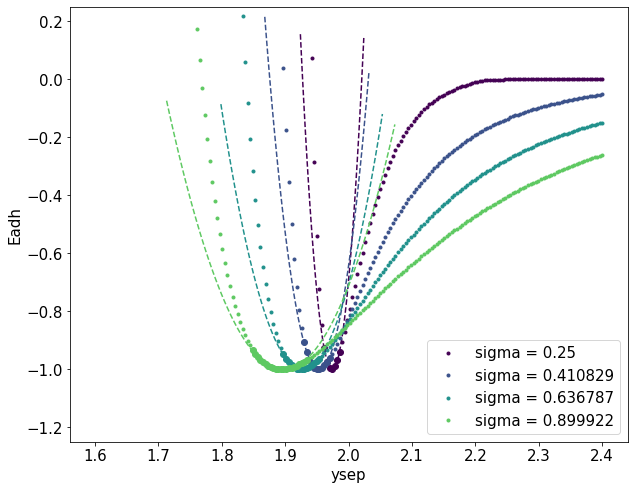

In [359]:
def harmonicfit(x,a,x0,y0):
    return a*(x-x0)**2 + y0
alist = []
x0list = []
y0list = []

cmap = plt.cm.viridis

fig, ax = plt.subplots(1,1,figsize=(10,8))
for i in range(len(sigma_list)):
    mask = (np.array(yseps[i])-tmin_list[i])**2 <= (0.05*sigma_list[i])**2
    ax.plot(np.array(yseps[i])[mask],np.array(eadhs[i])[mask],"o",color = cmap(i/(len(sigma_list))))
    ax.plot(np.array(yseps[i]),np.array(eadhs[i]),".",label=f"sigma = {sigma_list[i]}", color = cmap(i/(len(sigma_list))))
    xdata = np.array(yseps[i])[mask]
    ydata = np.array(eadhs[i])[mask]
    params, err = curve_fit(harmonicfit,xdata,ydata,p0=np.array([1,tmin_list[i],-emin_list[i]]))
    (abest,x0best,y0best)=params
    alist.append(abest)
    x0list.append(x0best)
    y0list.append(y0best)
    xfit = np.linspace(tmin_list[i]-0.2*sigma_list[i],tmin_list[i]+0.2*sigma_list[i],100)
    ax.plot(xfit,harmonicfit(xfit,abest,x0best,y0best),"--",color = cmap(i/(len(sigma_list))))
    
# ax.set_xlim(1.5,2.5)
# ax.set_ylim(-200,10)
ax.set_ylim(-1.25,0.25)
ax.legend(fontsize=15)
ax.set_xlabel("ysep",fontsize=15)
ax.set_ylabel("Eadh",fontsize=15)
ax.tick_params(labelsize=15)

print(f"sigma_list = np.array({sigma_list})")
print(f"alist = np.array({alist})")
print(f"tmin_list = np.array({tmin_list})")
print(f"x0list = np.array({x0list})")
print(f"emin_list = np.array({emin_list})")
print(f"y0list = np.array({y0list})")
print(f"epsilon_list = np.array({epsilon_list})")


In [355]:
sigmaeff_list = np.sqrt(np.abs(np.array(y0list))/np.array(alist))
sigmaeff_list

array([0.04663713, 0.07768123, 0.13442615, 0.19129742])

In [262]:
sigmaeff_list[3]/sigmaeff_list[0]

4.1018262989803445

In [263]:
sigma_list[3]/sigma_list[0]

3.599688

In [3]:
t0_list = np.array([4.434,2.35,1.2,0.6])
# t_list = t0_list + np.array(tmin_list)-1
dtlist = np.array(x0list)-1
t_list = t0_list + dtlist

t_list

NameError: name 'x0list' is not defined

In [375]:
dtlist

array([0.97414175, 0.95347335, 0.92720763, 0.89715429])

In [376]:
r0_list = np.array([54.053,32.893,21.221,15.015])
t_list/r0_list

array([0.10005257, 0.10043089, 0.10024069, 0.09971058])

In [377]:
epsilon_list

[1.4464536457630208e-05,
 7.149441531645948e-06,
 4.4305240601244645e-06,
 3.0055178781968955e-06]

In [2]:
0.007 * wx**4 / (t0_list**2 * r0_list**2)

NameError: name 'wx' is not defined

In [309]:
sigma_list

[0.25, 0.410829, 0.636787, 0.899922]

In [12]:
wx = 30
t0 = 0.6
r0 = 21.221
delta = (t0+1) * wx**2  / (8 * r0**2 )
0.13 * delta / np.sqrt((t0+1)/r0)


0.18923745470441242

In [19]:
wx = 30
t0 = 0.8
r0 = 21.221
0.007 * wx**4 / (t0**2 * r0**2)

19.673036339964995

In [21]:
delta = (t0+1) * wx**2  / (8 * r0**2 )
0.13 * delta / np.sqrt((t0+1)/r0)

0.20071663121395825

In [23]:
1.572-0.6 + 0.8

1.7720000000000002